<a href="https://colab.research.google.com/github/parnikapatole/Sqrock-Data-Science-week2-task1/blob/main/student_performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/StudentsPerformance.csv')

In [3]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [6]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [7]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [8]:
df = df.dropna()

In [12]:
df.corr(numeric_only=True)

,math score,reading score,writing score
math score,1.000000,0.817580,0.802642
reading score,0.817580,1.000000,0.954598
writing score,0.802642,0.954598,1.000000


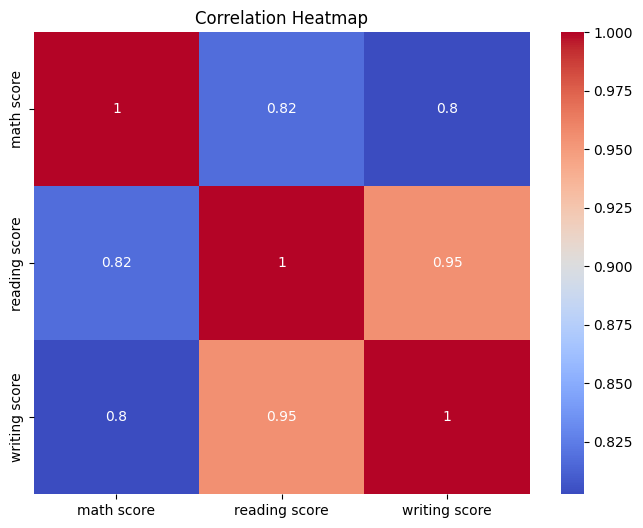

In [14]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [17]:
print(df.columns)

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')


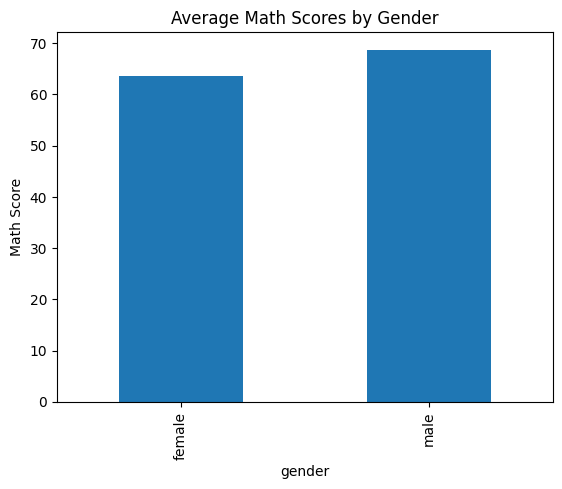

In [18]:
avg_scores = df.groupby('gender')['math score'].mean()

avg_scores.plot(kind='bar')

plt.title("Average Math Scores by Gender")
plt.ylabel("Math Score")

plt.show()

In [19]:
print(df.shape)

(1000, 8)


In [20]:
print(df.duplicated().sum())

0


In [21]:
top_students = df.sort_values(by='math score', ascending=False)

top_students.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
451,female,group E,some college,standard,none,100,92,97
458,female,group E,bachelor's degree,standard,none,100,100,100
962,female,group E,associate's degree,standard,none,100,100,100
149,male,group E,associate's degree,free/reduced,completed,100,100,93
623,male,group A,some college,standard,completed,100,96,86


In [22]:
print("Average Math Score:", df['math score'].mean())
print("Average Reading Score:", df['reading score'].mean())
print("Average Writing Score:", df['writing score'].mean())

Average Math Score: 66.089
Average Reading Score: 69.169
Average Writing Score: 68.054


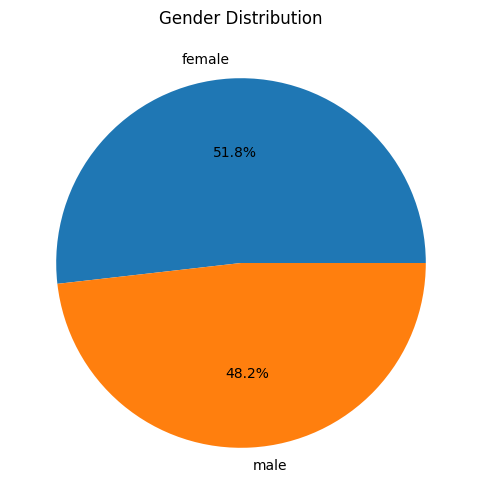

In [23]:
gender_counts = df['gender'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%'
)

plt.title("Gender Distribution")

plt.show()

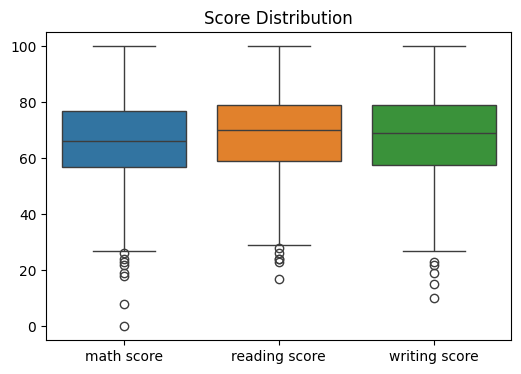

In [24]:
plt.figure(figsize=(6,4))

sns.boxplot(data=df[['math score',
                     'reading score',
                     'writing score']])

plt.title("Score Distribution")

plt.show()

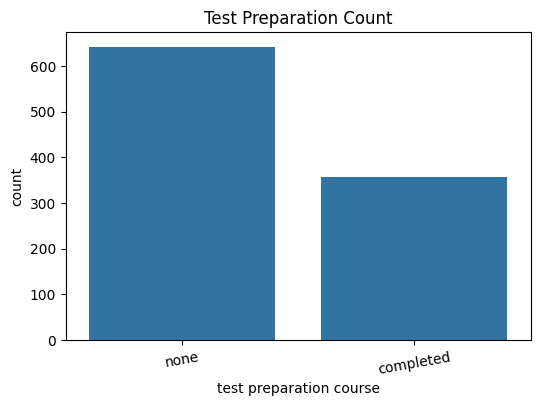

In [26]:
plt.figure(figsize=(6,4))

sns.countplot(x='test preparation course', data=df)

plt.title("Test Preparation Count")

plt.xticks(rotation=10)

plt.show()

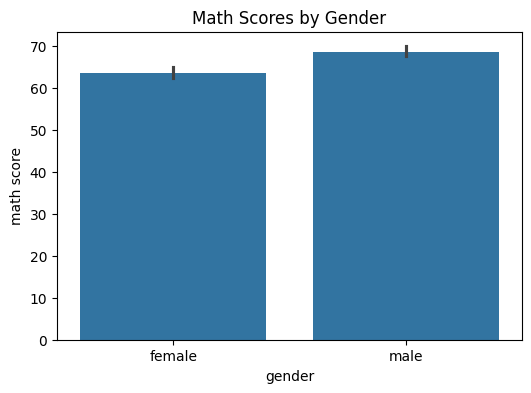

In [27]:
plt.figure(figsize=(6,4))

sns.barplot(
    x='gender',
    y='math score',
    data=df
)

plt.title("Math Scores by Gender")

plt.show()

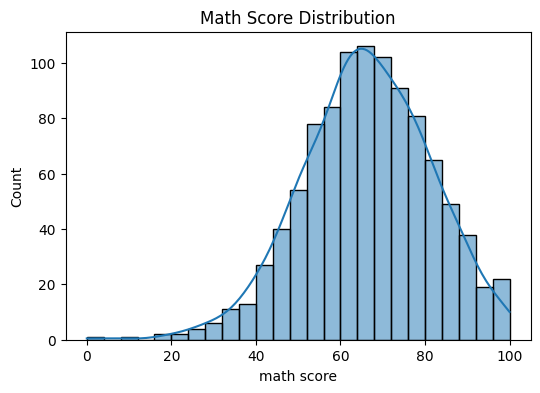

In [28]:
plt.figure(figsize=(6,4))

sns.histplot(df['math score'], kde=True)

plt.title("Math Score Distribution")

plt.show()

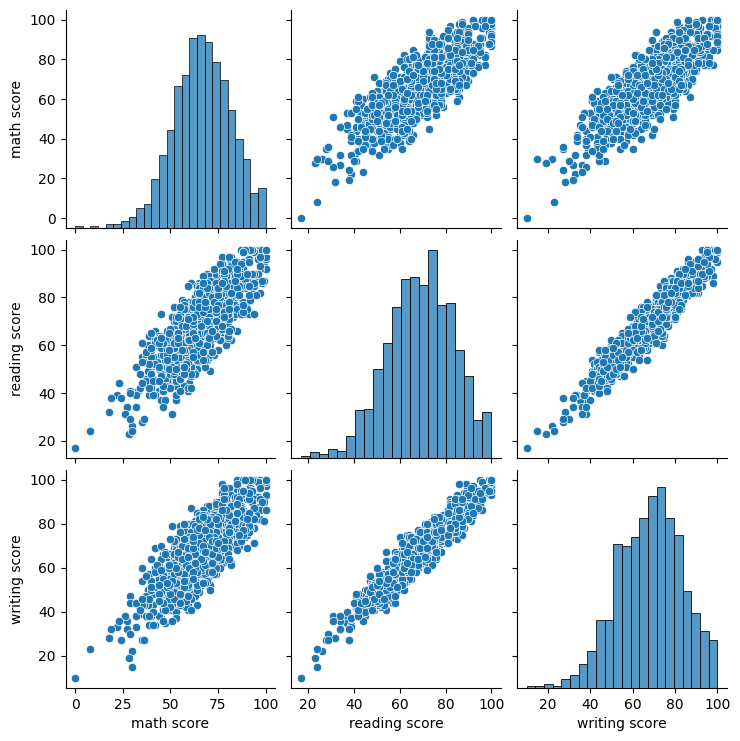

In [29]:
sns.pairplot(df[
    ['math score',
     'reading score',
     'writing score']
])

plt.show()

In [30]:
corr = df.corr(numeric_only=True)

print(corr)

               math score  reading score  writing score
math score       1.000000       0.817580       0.802642
reading score    0.817580       1.000000       0.954598
writing score    0.802642       0.954598       1.000000


In [32]:
top_reading = df.sort_values(
    by='reading score',
    ascending=False
)

top_reading.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
566,female,group E,bachelor's degree,free/reduced,completed,92,100,100
458,female,group E,bachelor's degree,standard,none,100,100,100
546,female,group A,some high school,standard,completed,92,100,97
594,female,group C,bachelor's degree,standard,completed,92,100,99
962,female,group E,associate's degree,standard,none,100,100,100


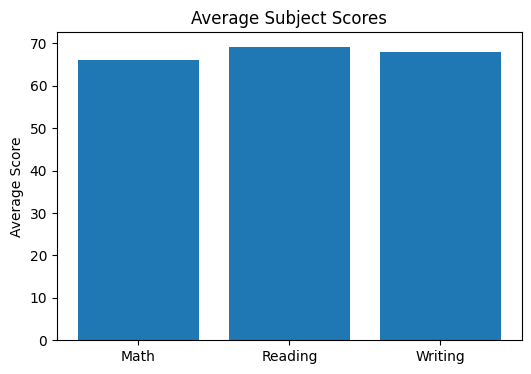

In [33]:
scores = [
    df['math score'].mean(),
    df['reading score'].mean(),
    df['writing score'].mean()
]

subjects = ['Math', 'Reading', 'Writing']

plt.figure(figsize=(6,4))

plt.bar(subjects, scores)

plt.title("Average Subject Scores")

plt.ylabel("Average Score")

plt.show()